# Caso real: segmentação de clientes

**Tema:** Aprendizado Não Supervisionado › Clustering

Um e-commerce com 5.000 clientes quer réguas de comunicação diferentes por
perfil de compra. Este notebook aplica o protocolo do `teoria.pdf` de ponta
a ponta: features RFM e de comportamento, tratamento de assimetria e
escala dentro de um `Pipeline`, escolha de $k$, perfis e nomes de negócio,
validação por uma variável de desfecho que **não** entrou no agrupamento,
estabilidade, e o que muda quando o modelo vai para produção.

Os dados são sintéticos e foram gerados a partir de 5 perfis ocultos — o
que nos permite, no fim, conferir o que o método recuperou. Num projeto
real, esse gabarito não existe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
CORES = np.array([AZUL, VERMELHO, VERDE, ROXO, AMBAR, "#5A5A5A", "#2A9D8F", "#E76F51"])
print("pronto")

pronto


## 1. Os dados

Recência, frequência e valor (RFM), mais ticket médio, proporção de
pedidos com cupom de desconto, tempo de cadastro e número de categorias
compradas. O `churn_90d` (cliente não comprou nos 90 dias seguintes) fica
**separado**: será usado só para validar os grupos.

In [2]:
def gera_clientes(n, semente):
    rng = np.random.default_rng(semente)
    # proporção, recência, frequência, ticket, % desconto, dias de cadastro, nº categorias, churn
    perfis = {
        "fiéis de alto valor":   (0.12, 8, 24, 230, 0.15, 900, 7, 0.03),
        "regulares":             (0.30, 30, 8, 120, 0.20, 700, 4, 0.10),
        "caçadores de promoção": (0.20, 22, 10, 60, 0.75, 500, 3, 0.20),
        "novos":                 (0.18, 12, 2, 100, 0.30, 35, 2, 0.25),
        "hibernando":            (0.20, 210, 3, 90, 0.25, 800, 2, 0.55),
    }
    nomes = list(perfis)
    seg = rng.choice(len(nomes), n, p=[perfis[k][0] for k in nomes])
    P = np.array([perfis[k][1:] for k in nomes])[seg]
    recencia = rng.lognormal(np.log(P[:, 0]), 0.45).round().clip(1, 365)
    freq = rng.poisson(P[:, 1]).clip(1, None)
    ticket = rng.lognormal(np.log(P[:, 2]), 0.25).round(2)
    valor = (freq * ticket * rng.lognormal(0, 0.1, n)).round(2)
    pct_desc = rng.beta(P[:, 3] * 12, (1 - P[:, 3]) * 12).round(3)
    dias_cad = np.maximum(rng.lognormal(np.log(P[:, 4]), 0.35).round(), recencia + 1)
    n_cat = rng.poisson(P[:, 5]).clip(1, 12)
    churn = (rng.random(n) < P[:, 6]).astype(int)
    df = pd.DataFrame({"recencia_dias": recencia, "frequencia_12m": freq, "valor_12m": valor,
                       "ticket_medio": ticket, "pct_com_desconto": pct_desc,
                       "dias_desde_cadastro": dias_cad, "n_categorias": n_cat})
    return df, np.array(nomes)[seg], churn


clientes, segmento_oculto, churn_90d = gera_clientes(5000, semente=2026)
print(clientes.head().to_string())
print(f"\nchurn médio da base: {churn_90d.mean():.1%}")

   recencia_dias  frequencia_12m  valor_12m  ticket_medio  pct_com_desconto  dias_desde_cadastro  n_categorias
0           55.0               7    1126.80        194.30             0.267                971.0             5
1            7.0               1     101.21         92.94             0.283                 37.0             1
2           11.0              13     718.52         59.48             0.654                485.0             4
3           41.0               4     258.27         64.49             0.106                622.0             1
4           57.0               7    1052.77        134.18             0.132                560.0             4

churn médio da base: 23.1%


## 2. Assimetria: por que o log vem antes da padronização

assimetria (skewness) de cada coluna:
recencia_dias          2.05
frequencia_12m         1.53
valor_12m              2.92
ticket_medio           1.71
pct_com_desconto       0.97
dias_desde_cadastro    0.38
n_categorias           1.18


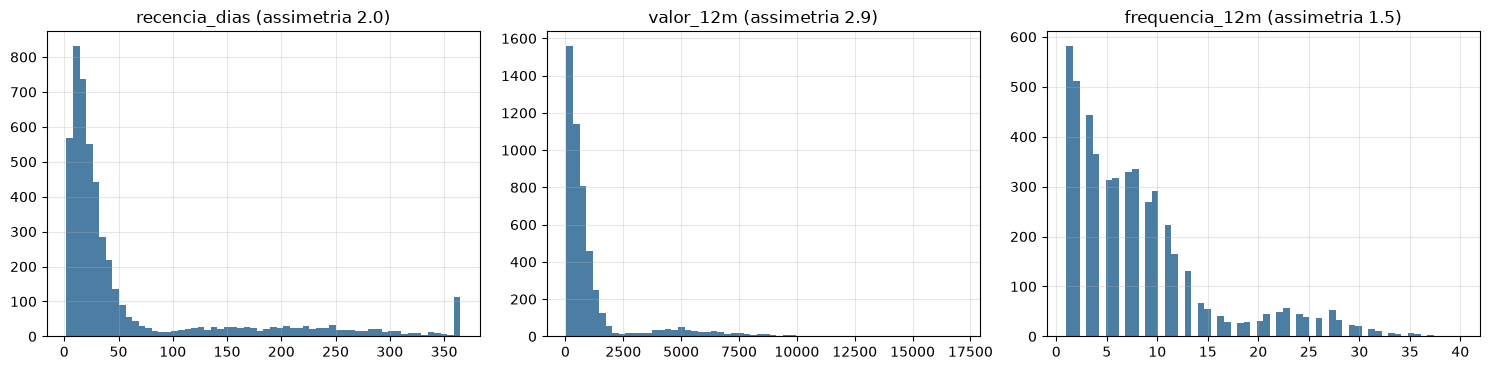

In [3]:
print("assimetria (skewness) de cada coluna:")
print(clientes.skew().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, ["recencia_dias", "valor_12m", "frequencia_12m"]):
    ax.hist(clientes[col], bins=60, color=AZUL, alpha=0.8)
    ax.set_title(f"{col} (assimetria {clientes[col].skew():.1f})")
plt.tight_layout(); plt.show()

Recência e valor têm cauda longa à direita. Padronizar sem log deixa os
clientes da cauda a muitos desvios-padrão de todo mundo, e as diferenças
absolutas grandes dominam a distância. Vamos medir o efeito comparando o
pipeline com e sem log contra os perfis ocultos.

In [4]:
colunas_log = ["recencia_dias", "frequencia_12m", "valor_12m", "ticket_medio",
               "dias_desde_cadastro", "n_categorias"]

def monta_pipeline(k, usar_log=True):
    passos = []
    if usar_log:
        passos.append(("log", ColumnTransformer(
            [("log1p", FunctionTransformer(np.log1p), colunas_log)],
            remainder="passthrough", verbose_feature_names_out=False)))
    passos += [("escala", StandardScaler()),
               ("kmeans", KMeans(n_clusters=k, n_init=10, random_state=0))]
    return Pipeline(passos)

for usar_log in [False, True]:
    pipe = monta_pipeline(5, usar_log).fit(clientes)
    rot = pipe.named_steps["kmeans"].labels_
    tamanhos = np.sort(np.bincount(rot))
    print(f"log={str(usar_log):5s}: tamanhos dos grupos {tamanhos} | "
          f"ARI vs. perfis ocultos = {adjusted_rand_score(segmento_oculto, rot):.3f}")

log=False: tamanhos dos grupos [ 554  918  993  997 1538] | ARI vs. perfis ocultos = 0.914
log=True : tamanhos dos grupos [ 574  942  983  994 1507] | ARI vs. perfis ocultos = 0.966


**Leitura:** com log, o agrupamento recupera melhor os perfis (ARI de 0,91
para 0,97). O efeito aqui é moderado porque os perfis sintéticos são bem
separados; em bases reais, com clientes que gastam 100 vezes a mediana,
a diferença costuma ser bem maior — sem log, surgem "segmentos" de meia
dúzia de clientes extremos.

## 3. Escolhendo k

In [5]:
transformador = monta_pipeline(2)[:-1].fit(clientes)   # log + escala, sem o k-means
Z = transformador.transform(clientes)
linhas = []
for k in range(2, 9):
    rot = KMeans(k, n_init=10, random_state=0).fit_predict(Z)
    linhas.append({"k": k,
                   "silhueta": silhouette_score(Z, rot, sample_size=3000, random_state=0),
                   "Calinski-Harabasz": calinski_harabasz_score(Z, rot),
                   "Davies-Bouldin": davies_bouldin_score(Z, rot)})
criterios = pd.DataFrame(linhas).set_index("k")
print(criterios.round(3).to_string())

   silhueta  Calinski-Harabasz  Davies-Bouldin
k                                             
2     0.261           2091.005           1.343
3     0.320           2338.089           1.208
4     0.409           3024.605           0.909
5     0.427           3638.116           0.892
6     0.372           3252.915           1.091
7     0.333           2930.453           1.243
8     0.303           2692.454           1.412


Os três índices apontam para $k=5$ — e 5 réguas de comunicação é um
número que um time de CRM consegue operar. Seguimos com $k=5$.

## 4. Perfis na escala original e nomes de negócio

O perfil de cada grupo é lido na **escala original** (medianas), porque é
assim que o negócio vai entender. Os nomes são dados por regras explícitas
sobre o perfil — escritas aqui em código para o notebook ser reproduzível;
num projeto real, essa etapa é uma conversa com o time de negócio.

In [6]:
modelo = monta_pipeline(5).fit(clientes)
grupo = modelo.named_steps["kmeans"].labels_
perfil = clientes.groupby(grupo).median()
perfil["tamanho"] = np.bincount(grupo)

def nomeia(perfil):
    nomes, livres = {}, set(perfil.index)
    for nome, col, fn in [("hibernando", "recencia_dias", "idxmax"),
                          ("novos", "dias_desde_cadastro", "idxmin"),
                          ("caçadores de promoção", "pct_com_desconto", "idxmax"),
                          ("fiéis de alto valor", "valor_12m", "idxmax")]:
        g = getattr(perfil.loc[sorted(livres), col], fn)()
        nomes[g] = nome
        livres.remove(g)
    nomes[livres.pop()] = "regulares"
    return nomes

nomes = nomeia(perfil)
perfil.index = [nomes[g] for g in perfil.index]
print(perfil.round(2).to_string())

                       recencia_dias  frequencia_12m  valor_12m  ticket_medio  pct_com_desconto  dias_desde_cadastro  n_categorias  tamanho
caçadores de promoção           22.0            10.0     579.40         59.48              0.76                513.0           3.0      983
fiéis de alto valor              8.0            24.0    5262.92        229.96              0.13                889.5           7.0      574
novos                           12.0             2.0     181.68         99.39              0.29                 35.0           2.0      942
hibernando                     216.0             3.0     240.12         89.62              0.23                800.0           2.0      994
regulares                       31.0             8.0     912.76        119.95              0.18                694.0           4.0     1507


## 5. Validação pelo desfecho: churn em 90 dias

O churn **não** entrou no agrupamento. Se os grupos forem reais e
acionáveis, o churn deve diferir entre eles.

taxa de churn em 90 dias por segmento:
segmento
fiéis de alto valor       2.4%
regulares                10.6%
caçadores de promoção    20.7%
novos                    25.3%
hibernando               54.5%

qui-quadrado = 829.5, p-valor = 3.13e-178


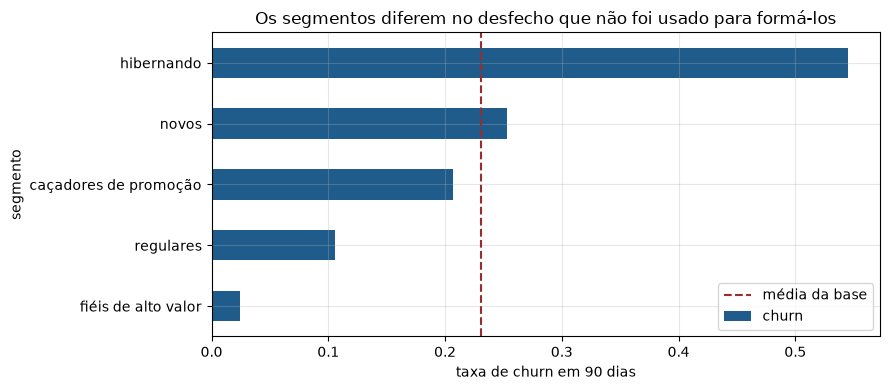

In [7]:
rotulo = pd.Series([nomes[g] for g in grupo], name="segmento")
tabela = pd.crosstab(rotulo, churn_90d)
taxa = rotulo.to_frame().assign(churn=churn_90d).groupby("segmento")["churn"].mean()
chi2, p, _, _ = chi2_contingency(tabela)
print("taxa de churn em 90 dias por segmento:")
print((taxa.sort_values() * 100).round(1).astype(str).add("%").to_string())
print(f"\nqui-quadrado = {chi2:.1f}, p-valor = {p:.2e}")

fig, ax = plt.subplots(figsize=(9, 4))
taxa.sort_values().plot.barh(ax=ax, color=AZUL)
ax.axvline(churn_90d.mean(), color=VERMELHO, ls="--", label="média da base")
ax.set_xlabel("taxa de churn em 90 dias"); ax.legend()
ax.set_title("Os segmentos diferem no desfecho que não foi usado para formá-los")
plt.tight_layout(); plt.show()

**Leitura esperada:** "hibernando" tem churn muito acima da média e
"fiéis de alto valor" muito abaixo — a variável de desfecho confirma que
os grupos capturam comportamento real. O teste qui-quadrado (tema 1) só
formaliza o que o gráfico já mostra.

## 6. Estabilidade por bootstrap

In [8]:
aris = []
for b in range(20):
    idx = np.random.default_rng(b).choice(len(clientes), len(clientes), replace=True)
    km_b = KMeans(5, n_init=10, random_state=b).fit(Z[idx])
    aris.append(adjusted_rand_score(grupo, km_b.predict(Z)))
print(f"ARI entre a segmentação original e as reamostradas: "
      f"média {np.mean(aris):.3f}, mínimo {np.min(aris):.3f}")

ARI entre a segmentação original e as reamostradas: média 0.997, mínimo 0.996


## 7. Produção: clientes novos e rótulos que não trocam de nome

Dois cuidados quando a segmentação roda todo mês:

1. **Clientes novos** são atribuídos com `predict` do pipeline já treinado
   (centróides fixos) — não se reagrupa a base para cada cliente novo.
2. **Retreinos** geram grupos com ids arbitrários. Alinhamos os ids do
   modelo novo com os do antigo pelo algoritmo húngaro sobre a distância
   entre centróides, para que "fiéis de alto valor" continue sendo
   "fiéis de alto valor".

In [9]:
novos_clientes, _, _ = gera_clientes(8, semente=99)
novos_clientes["segmento_previsto"] = [nomes[g] for g in modelo.predict(novos_clientes)]
print(novos_clientes[["recencia_dias", "frequencia_12m", "valor_12m",
                      "pct_com_desconto", "segmento_previsto"]].to_string())

   recencia_dias  frequencia_12m  valor_12m  pct_com_desconto      segmento_previsto
0           14.0              16     797.22             0.708  caçadores de promoção
1           33.0              13    1012.98             0.832  caçadores de promoção
2           30.0               8     541.70             0.777  caçadores de promoção
3          365.0               5     736.88             0.389             hibernando
4           33.0              11     581.73             0.903  caçadores de promoção
5           25.0               7     517.46             0.745  caçadores de promoção
6           35.0               5     699.21             0.201              regulares
7           34.0               8     420.16             0.912  caçadores de promoção


In [10]:
clientes_mes2, _, _ = gera_clientes(5000, semente=2027)
modelo_mes2 = monta_pipeline(5).set_params(kmeans__random_state=7).fit(clientes_mes2)
c_antigo = modelo.named_steps["kmeans"].cluster_centers_
# centróides do mês 2 levados para o espaço do modelo antigo (desfaz a escala nova, aplica a antiga)
esc_nova, esc_antiga = modelo_mes2.named_steps["escala"], modelo.named_steps["escala"]
c_novo = esc_antiga.transform(esc_nova.inverse_transform(
    modelo_mes2.named_steps["kmeans"].cluster_centers_))
custo = ((c_antigo[:, None, :] - c_novo[None, :, :]) ** 2).sum(axis=2)
linha, coluna = linear_sum_assignment(custo)
mapa = {novo: nomes[antigo] for antigo, novo in zip(linha, coluna)}
print("id no modelo do mês 2 -> nome herdado do mês 1:")
for novo in sorted(mapa):
    print(f"  grupo {novo} -> {mapa[novo]}")

id no modelo do mês 2 -> nome herdado do mês 1:
  grupo 0 -> novos
  grupo 1 -> regulares
  grupo 2 -> hibernando
  grupo 3 -> caçadores de promoção
  grupo 4 -> fiéis de alto valor


## 8. Conferindo contra o gabarito (só possível com dados sintéticos)

In [11]:
print(pd.crosstab(pd.Series(segmento_oculto, name="perfil oculto"),
                  rotulo.rename("segmento encontrado")).to_string())
print(f"\nARI = {adjusted_rand_score(segmento_oculto, rotulo):.3f}")

segmento encontrado    caçadores de promoção  fiéis de alto valor  hibernando  novos  regulares
perfil oculto                                                                                  
caçadores de promoção                    980                    0           1      0         12
fiéis de alto valor                        0                  570           0      0          2
hibernando                                 0                    0         974      0         17
novos                                      0                    0           0    940          0
regulares                                  3                    4          19      2       1476



ARI = 0.966


## O que levar deste notebook

- A ordem das transformações importa: log nas colunas de cauda longa,
  depois padronização, tudo dentro de um `Pipeline`.
- Os índices internos descartam valores ruins de $k$; a escolha final
  combina índice e capacidade operacional do negócio.
- Perfis são lidos na escala original e viram nomes de negócio — um grupo
  sem nome acionável é um grupo que ninguém vai usar.
- A validação mais convincente é por uma variável de desfecho que ficou de
  fora do agrupamento.
- Em produção: `predict` com centróides fixos para clientes novos e
  alinhamento de rótulos entre retreinos.

→ Próximo: **Exercícios** do módulo, e depois o módulo 2, **Redução de
Dimensionalidade**.